In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math
import torch
import pickle
from collections import Counter
import sys
import os

In [2]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.model_utils import eval_predictions, compare_models, save_model

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.3

## Load Data

In [4]:
with open("all_segments.pkl", "rb") as f:
    segments = pickle.load(f)

In [5]:
pulses_df = pd.read_csv("pulses.csv")

In [6]:
drop_cols = ["row_id", "start_idx",	"min_idx",	"end_idx"]

In [7]:
X = pulses_df.drop(columns=drop_cols, errors="ignore")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering con K-Means

KMeans codo: 100%|██████████| 13/13 [00:22<00:00,  1.69s/it]


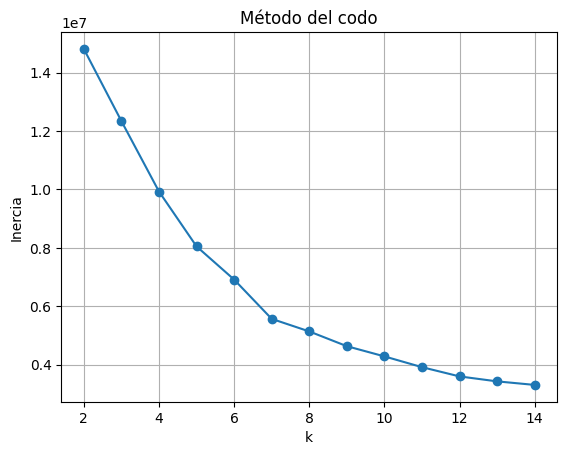

In [8]:
inertias = []
K_range = range(2, 15)
for k in tqdm(K_range, desc="KMeans codo"):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.title("Método del codo")
plt.grid()
plt.xlabel("k"); plt.ylabel("Inercia"); plt.show()

In [9]:
best_k = 8
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled)
#pulses_df["cluster"] = labels

### PCA para visualización 2D/3D

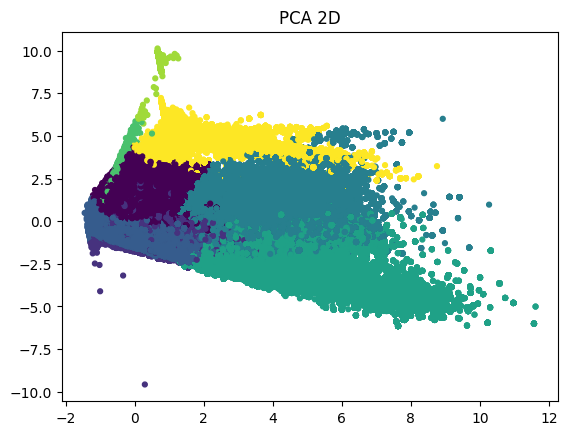

In [10]:
pca2 = PCA(n_components=2)
Xp2 = pca2.fit_transform(X_scaled)
plt.scatter(Xp2[:,0], Xp2[:,1], c=labels, s=12, cmap="viridis")
plt.title("PCA 2D"); plt.show()

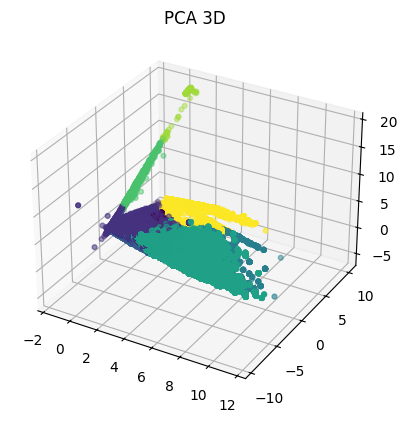

In [11]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3)
Xp3 = pca3.fit_transform(X_scaled)
fig = plt.figure(); ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xp3[:,0], Xp3[:,1], Xp3[:,2], c=labels, s=12, cmap="viridis")
plt.title("PCA 3D"); plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math

def _cut_around_min(seg: np.ndarray, n_before: int, n_after: int):
    if len(seg) == 0:
        return seg
    kmin = int(np.argmin(seg))
    a = max(0, kmin - n_before)
    b = min(len(seg), kmin + n_after + 1)
    return seg[a:b]

def _align_and_normalize(seg: np.ndarray, align='min', normalize=True, scale=None, eps=1e-9):
    s = seg.astype(float).copy()
    if normalize:
        s = s - np.median(s)
    if scale == 'maxabs':
        m = np.max(np.abs(s))
        if m > eps:
            s = s / m
    elif scale == 'robust':
        p5, p95 = np.percentile(s, [5, 95])
        rng = p95 - p5
        if rng > eps:
            s = (s - p5) / rng
    return s

def _resample_to_fixed(seg: np.ndarray, out_len: int):
    L = len(seg)
    if L == 0:
        return np.zeros(out_len)
    if L == out_len:
        return seg
    x_old = np.linspace(0, 1, L)
    x_new = np.linspace(0, 1, out_len)
    return np.interp(x_new, x_old, seg)

def compare_pulse_segments_overlay(
    segments,labels,mode='same',
    classes=None,n=12,n_before=20,n_after=40,
    align='min',normalize=True,resample_len=120,
    show_median=True,title=None,
    rng_seed=42,ax=None, alpha=0.45, median_kwargs=None,      
    plot_kwargs=None, show_legend=True,        
    show_now=None,
    scale=None, # None | "maxabs" | "robust"
    y_percentile=None
):
    """
    Dibuja SÓLO los pulsos recortados alrededor del mínimo.
    Si 'ax' es None, crea su propia figura. Si 'ax' es un eje, dibuja ahí.
    Retorna: dict con {'ax', 'waves', 'median'} para reutilizar resultados.
    """
    labs = np.asarray(labels)
    if mode == 'same':
        if not classes or len(classes) != 1:
            raise ValueError("Para mode='same' usa classes=[clase].")
        c = classes[0]
        idx = np.where(labs == c)[0]
        title = title or f"Pulsos superpuestos (misma clase {c})"
    else:
        if not classes or len(classes) < 2:
            uniq = np.unique(labs)
            classes = list(uniq[:2])
        idx = np.concatenate([np.where(labs == c)[0] for c in classes])
        title = title or f"Pulsos superpuestos (clases {classes})"

    if len(idx) == 0:
        print("No hay pulsos para los criterios indicados.")
        return {'ax': ax, 'waves': [], 'median': None}

    rng = np.random.default_rng(rng_seed)
    idx = rng.choice(idx, size=min(n, len(idx)), replace=False)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
        created_fig = True

    waves = []
    _plot_kwargs = dict()
    if plot_kwargs:
        _plot_kwargs.update(plot_kwargs)

    for k in idx:
        seg = np.asarray(segments[k]["values"]).astype(float)
        seg = _cut_around_min(seg, n_before=n_before, n_after=n_after)
        seg = _align_and_normalize(seg, align=align, normalize=normalize, scale=scale)
        seg = _resample_to_fixed(seg, out_len=resample_len)
        waves.append(seg)
        ax.plot(seg, alpha=alpha, **_plot_kwargs)

    med = None
    if show_median and len(waves) > 0:
        med = np.median(np.vstack(waves), axis=0)
        mk = dict(lw=2.5, label="Mediana", zorder=10)
        if median_kwargs:
            mk.update(median_kwargs)
        ax.plot(med, **mk)

    # Ajuste de Y por percentiles (por subplot)
    if y_percentile is not None and len(waves) > 0:
        lo, hi = np.percentile(np.hstack(waves), y_percentile)
        if lo == hi:  # evita colapso si todos son iguales
            lo -= 1.0
            hi += 1.0
        ax.set_ylim(lo, hi)

    ax.set_title(title)
    ax.set_xlabel("Muestras (re-muestreadas)")
    ax.set_ylabel("Amplitud normalizada" if normalize else "Amplitud")
    if show_median and show_legend:
        ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Decidir si llamar plt.show()
    if show_now is None:
        # Si nosotros creamos la figura, mostramos; si no, dejamos al caller.
        show_now = created_fig
    if show_now and created_fig:
        plt.show()

    return {'ax': ax, 'waves': waves, 'median': med}


def compare_pulse_subplots(
    segments, labels, classes_list,
    ncols=3, figsize=(12, 4), sharey=False, **kwargs
):
    n = len(classes_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=sharey)
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(classes_list):
        compare_pulse_segments_overlay(
            segments, labels,
            mode='same', classes=[c],
            ax=axes[i],
            show_now=False,
            show_legend=(i == 0),
            **kwargs
        )
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    return axes

In [13]:
#compare_pulse_segments_overlay(
#    segments, labels,
#    mode='same', classes=[1],
#    n=15, n_before=20, n_after=40,
#    align='min', normalize=True, resample_len=120, show_median=True
#)

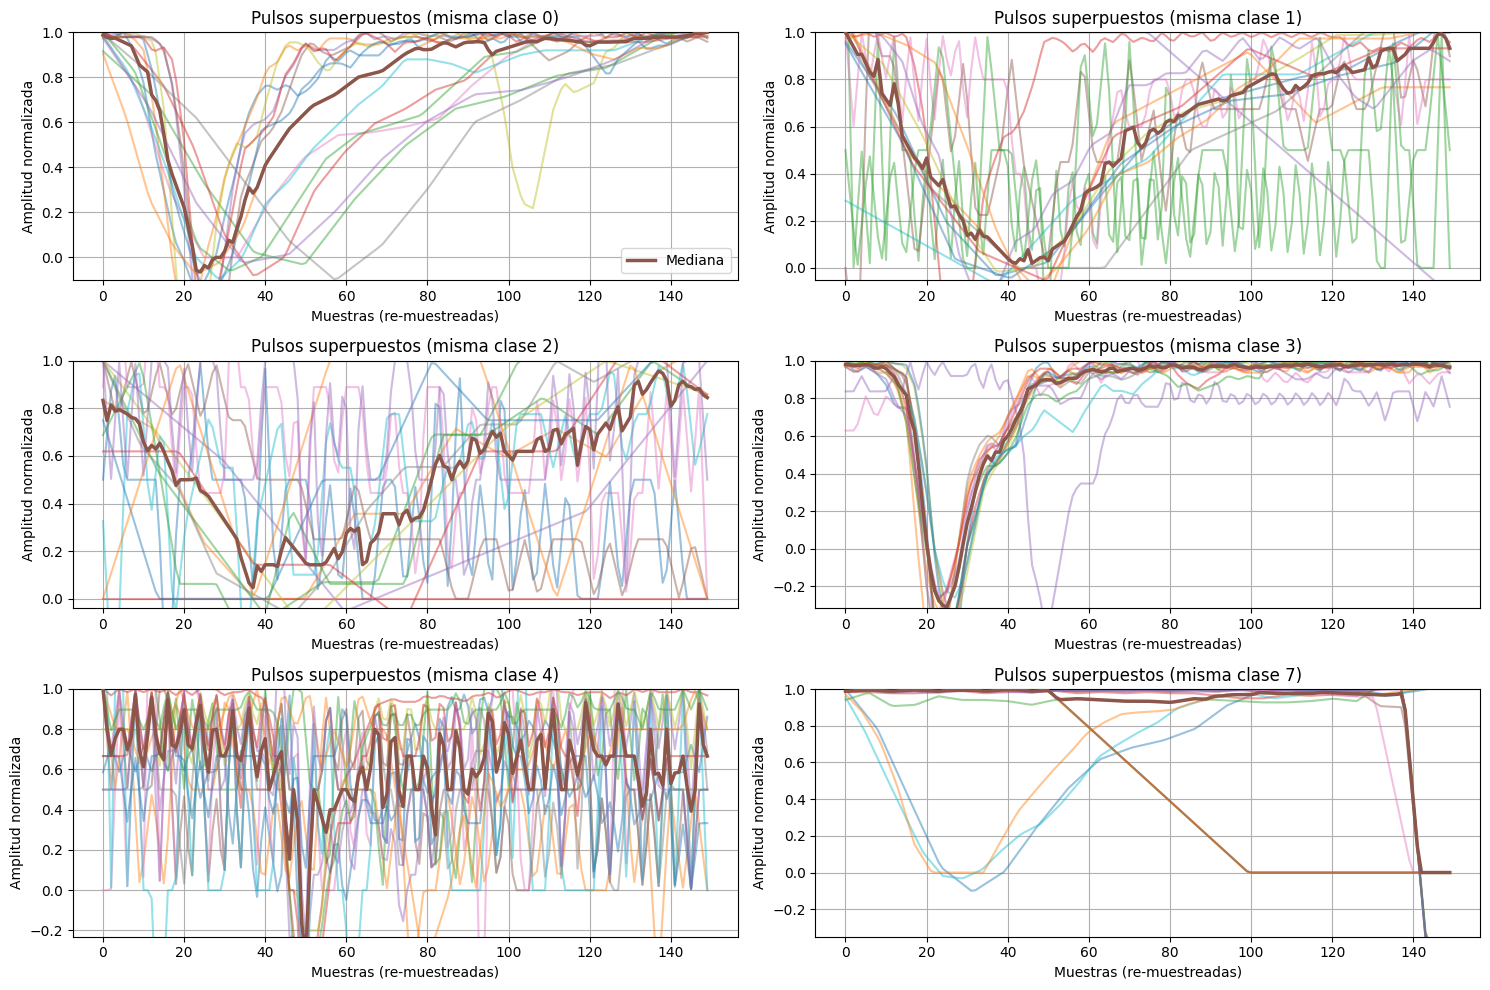

array([<Axes: title={'center': 'Pulsos superpuestos (misma clase 0)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 1)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 2)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 3)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 4)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 7)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>],
      dtype=object)

In [14]:

compare_pulse_subplots(
    segments, labels,
    classes_list=[0,1,2,3,4,7],
    ncols=2, figsize=(15,10),
    n=15, n_before=25, n_after=50,
    resample_len=150, normalize=True,
    scale="robust", y_percentile=(2, 98)
)

In [15]:

element_counts = Counter(labels)
print(f"Counts of all elements : {element_counts}")

Counts of all elements : Counter({np.int32(2): 1252551, np.int32(0): 517775, np.int32(3): 226776, np.int32(1): 201172, np.int32(4): 103253, np.int32(7): 61185, np.int32(5): 2706, np.int32(6): 1035})


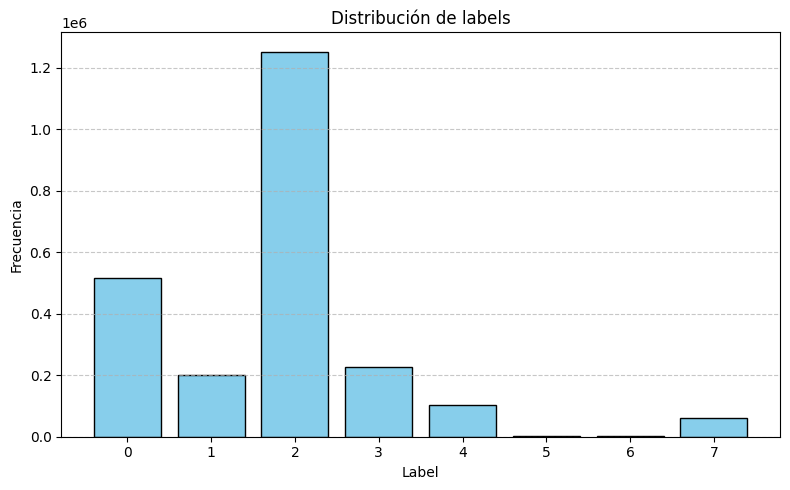

In [16]:
unique, counts = np.unique(labels, return_counts=True)

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Distribución de labels")
plt.xlabel("Label")
plt.ylabel("Frecuencia")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Modelos de  Clasificación

#### Dividir dataset

In [17]:
#Xtr, Xte, ytr, yte = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)

In [18]:
X.head()

,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,113.0,195.0,82.0,12,528.0,6,3,8,13.666667
1,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
2,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
3,157.0,195.0,38.0,153,396.0,5,76,76,38.000000
4,157.0,195.0,38.0,153,396.0,5,76,76,38.000000


In [19]:
feature_cols = list(X.columns)

In [20]:
X_trval, X_te, y_trval, y_te = train_test_split(
    X, labels, test_size=TEST_SIZE, random_state=42, stratify=labels
)
# luego separamos val del resto
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25, random_state=42, stratify=y_trval
)

In [21]:
# --- scaler (ajustar SOLO con train) ---
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s  = scaler.transform(X_te)

num_classes = len(np.unique(labels))

## Modelo de Arbol

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [23]:
# Entrenamos el árbol (usamos train+val para que tenga más datos; o sólo train si prefieres)
X_train_for_tree = np.vstack([X_tr_s, X_val_s])
y_train_for_tree = np.concatenate([y_tr, y_val])

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,        # ajusta según sobreajuste
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train_for_tree, y_train_for_tree)

# Predicción en test
proba_tree = dt.predict_proba(X_te_s)
yhat_dt = proba_tree.argmax(axis=1)


In [24]:
# Importancias
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top importances (árbol):")
print(importances.head(10))

Top importances (árbol):
depth                 0.491194
baseline_local        0.223182
recovery_time         0.174285
width_samples         0.102340
fwhm_samples          0.003557
area_under_pulse      0.002084
snr_depth_over_mad    0.001394
rise_time             0.001207
min_value             0.000755
dtype: float64


=== Métricas agregadas ===
Macro     -> P: 0.8431 | R: 0.8393 | F1: 0.8411
Weighted  -> P: 0.9762 | R: 0.9771 | F1: 0.9766

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    155333
           1       0.97      0.95      0.96     60352
           2       1.00      0.99      0.99    375765
           3       0.95      0.94      0.95     68033
           4       0.86      0.89      0.87     30976
           5       0.00      0.00      0.00       812
           6       1.00      0.98      0.99       310
           7       1.00      0.98      0.99     18355

    accuracy                           0.98    709936
   macro avg       0.84      0.84      0.84    709936
weighted avg       0.98      0.98      0.98    709936



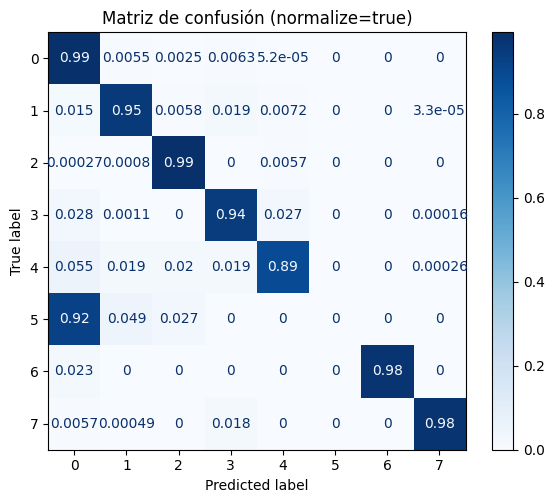


ROC-AUC multiclase:
  micro-average: 0.9978
  macro-average (ovr): 0.9764


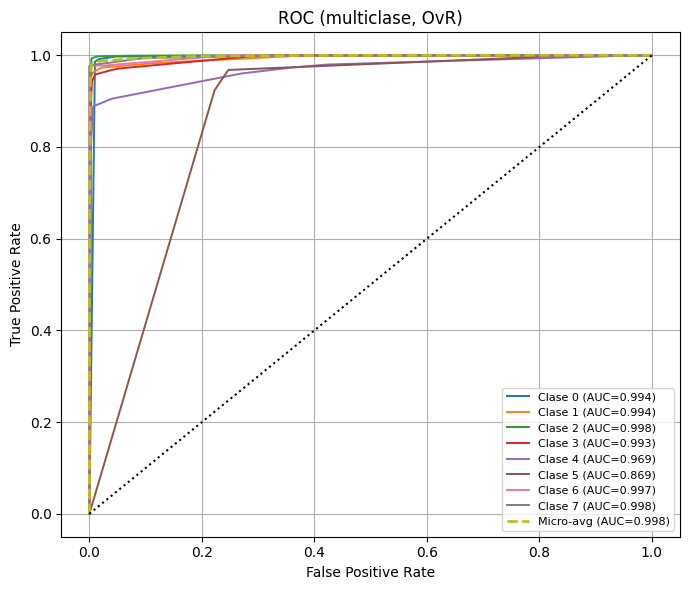


Average Precision multiclase:
  micro-average AP: 0.9875
  clase 0 AP: 0.9630
  clase 1 AP: 0.9618
  clase 2 AP: 0.9966
  clase 3 AP: 0.9530
  clase 4 AP: 0.8472
  clase 5 AP: 0.0046
  clase 6 AP: 0.9775
  clase 7 AP: 0.9808


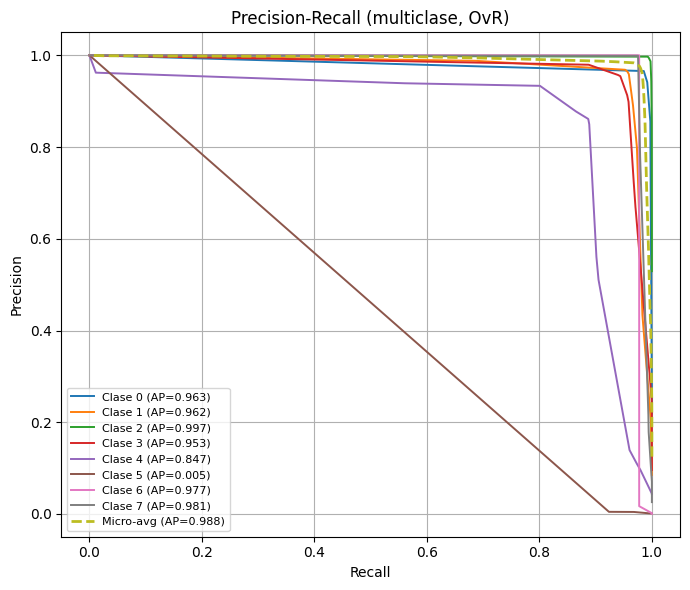

In [25]:
_ = eval_predictions(y_true=y_te, y_pred=proba_tree, plot_cm=True, plot_roc=True, plot_pr=True)

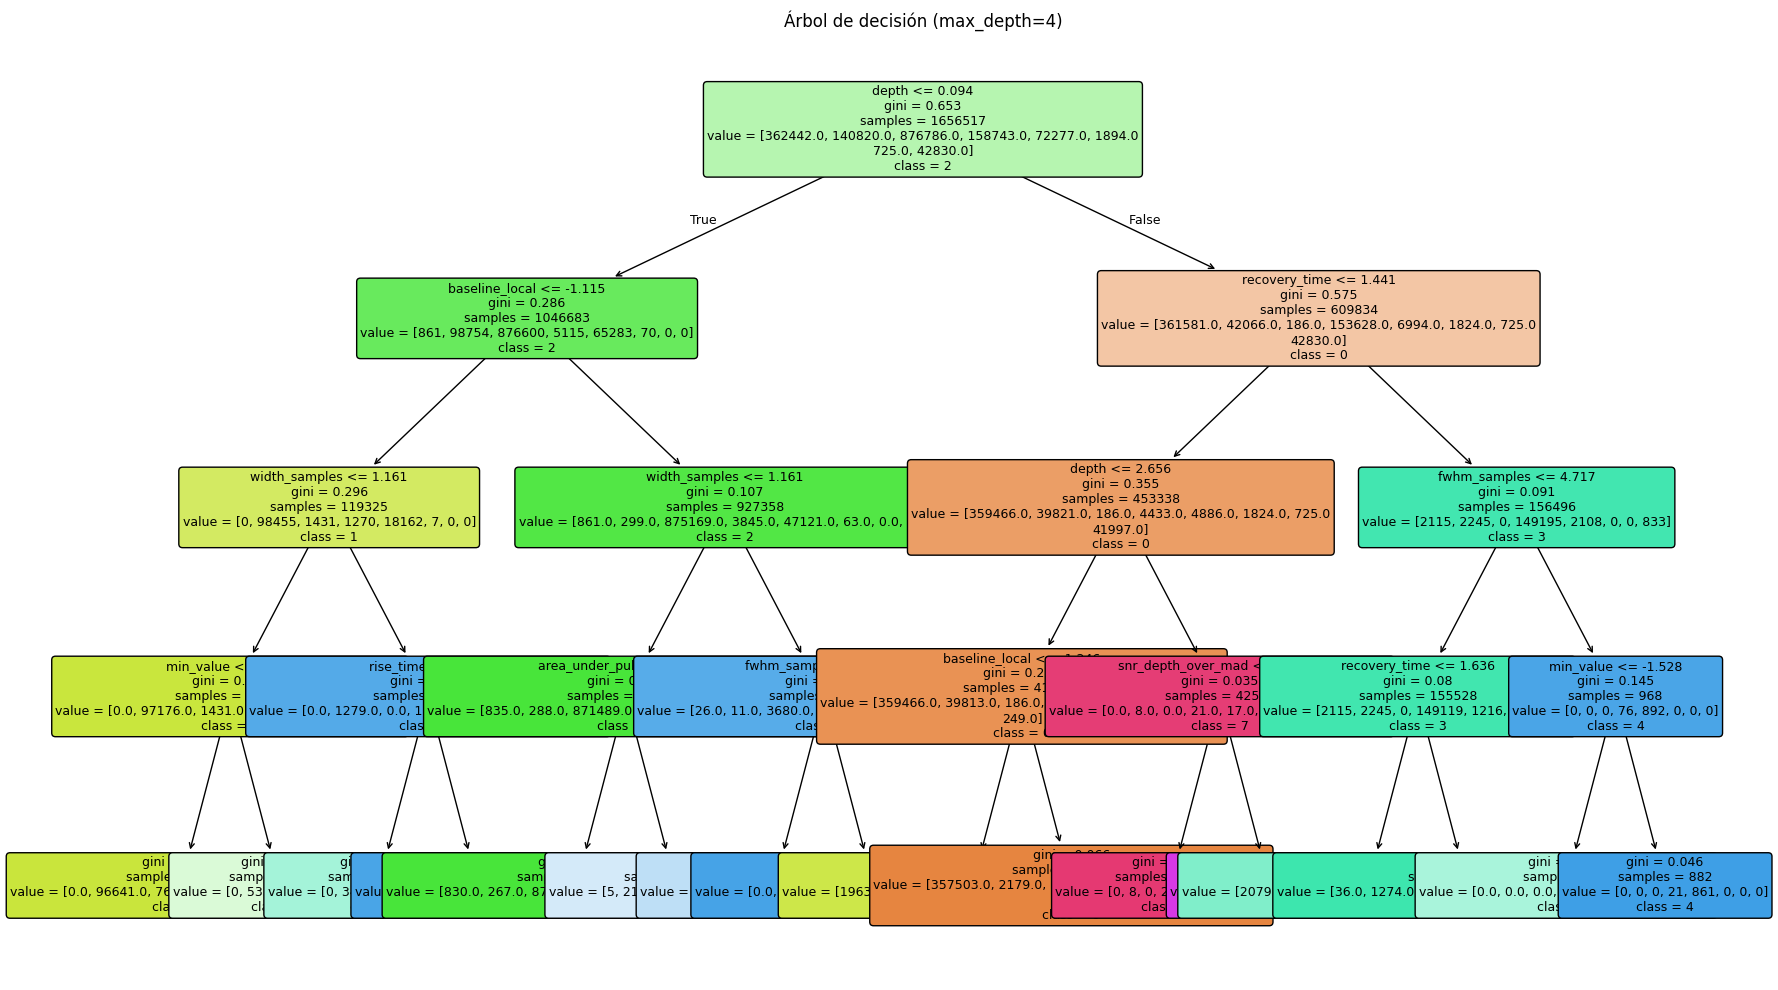

In [26]:
# Visualizar el árbol
plt.figure(figsize=(18,10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=[str(c) for c in np.unique(labels)],
    filled=True, rounded=True, fontsize=9
)
plt.title("Árbol de decisión (max_depth=4)")
plt.tight_layout()
plt.show()

## XGBoost

In [27]:
from xgboost import XGBClassifier
from xgboost import plot_importance

In [28]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    max_leaves=3,
    learning_rate=0.005,
    eval_metric="mlogloss",
    early_stopping_rounds=5,       
    verbosity=2,         
    use_label_encoder=False
)

# Entrenar con early stopping
xgb.fit(
    X_tr_s, y_tr,
    eval_set=[(X_tr_s, y_tr), (X_val_s, y_val)],             
    verbose=True        
)

[20:19:44] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (1242387, 9, 11181483).
[20:19:44] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (414130, 9, 3727170).


/opt/conda/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [20:19:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:2.06372	validation_1-mlogloss:2.06371
[1]	validation_0-mlogloss:2.04826	validation_1-mlogloss:2.04825
[2]	validation_0-mlogloss:2.03307	validation_1-mlogloss:2.03305
[3]	validation_0-mlogloss:2.01813	validation_1-mlogloss:2.01811
[4]	validation_0-mlogloss:2.00388	validation_1-mlogloss:2.00385
[5]	validation_0-mlogloss:1.98984	validation_1-mlogloss:1.98981
[6]	validation_0-mlogloss:1.97601	validation_1-mlogloss:1.97597
[7]	validation_0-mlogloss:1.96238	validation_1-mlogloss:1.96234
[8]	validation_0-mlogloss:1.94895	validation_1-mlogloss:1.94891
[9]	validation_0-mlogloss:1.93571	validation_1-mlogloss:1.93567
[10]	validation_0-mlogloss:1.92265	validation_1-mlogloss:1.92261
[11]	validation_0-mlogloss:1.90978	validation_1-mlogloss:1.90974
[12]	validation_0-mlogloss:1.89709	validation_1-mlogloss:1.89704
[13]	validation_0-mlogloss:1.88458	validation_1-mlogloss:1.88452
[14]	validation_0-mlogloss:1.87223	validation_1-mlogloss:1.87217
[15]	validation_0-mlogloss:1.86004	

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,5
,enable_categorical,False
,eval_metric,'mlogloss'


### Feature Importance

In [29]:
feature_cols

['min_value',
 'baseline_local',
 'depth',
 'width_samples',
 'area_under_pulse',
 'fwhm_samples',
 'rise_time',
 'recovery_time',
 'snr_depth_over_mad']

Top features por importancia (gain):


<Figure size 800x600 with 0 Axes>

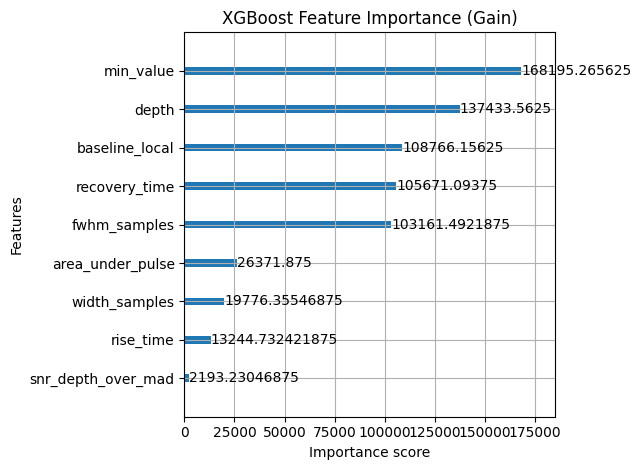

In [30]:
booster = xgb.get_booster()
booster.feature_names = feature_cols

importance_dict = booster.get_score(importance_type='gain')
importance_df = (
    pd.DataFrame({
        'feature': list(importance_dict.keys()),
        'importance': list(importance_dict.values())
    })
    .sort_values(by='importance', ascending=False)
)

# Mostrar top features
print("Top features por importancia (gain):")
importance_df.head(10)

# --- Graficar ---
plt.figure(figsize=(8,6))
plot_importance(booster, importance_type='gain', max_num_features=15)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

=== Métricas agregadas ===
Macro     -> P: 0.9683 | R: 0.9237 | F1: 0.9379
Weighted  -> P: 0.9688 | R: 0.9673 | F1: 0.9651

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    155333
           1       0.95      0.98      0.96     60352
           2       0.99      1.00      0.99    375765
           3       0.86      0.96      0.90     68033
           4       0.98      0.55      0.71     30976
           5       1.00      0.94      0.97       812
           6       1.00      1.00      1.00       310
           7       0.99      0.98      0.99     18355

    accuracy                           0.97    709936
   macro avg       0.97      0.92      0.94    709936
weighted avg       0.97      0.97      0.97    709936



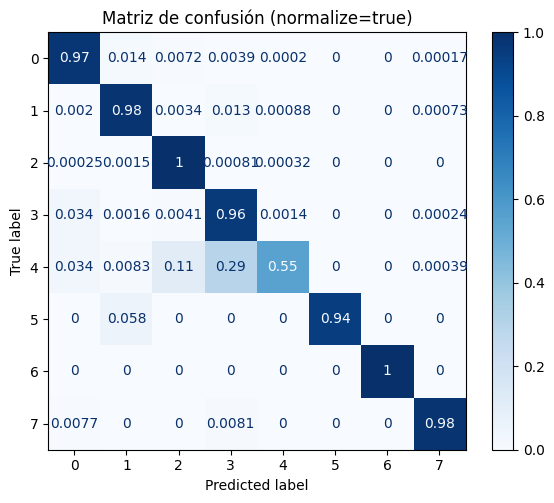


ROC-AUC multiclase:
  micro-average: 0.9984
  macro-average (ovr): 0.9979


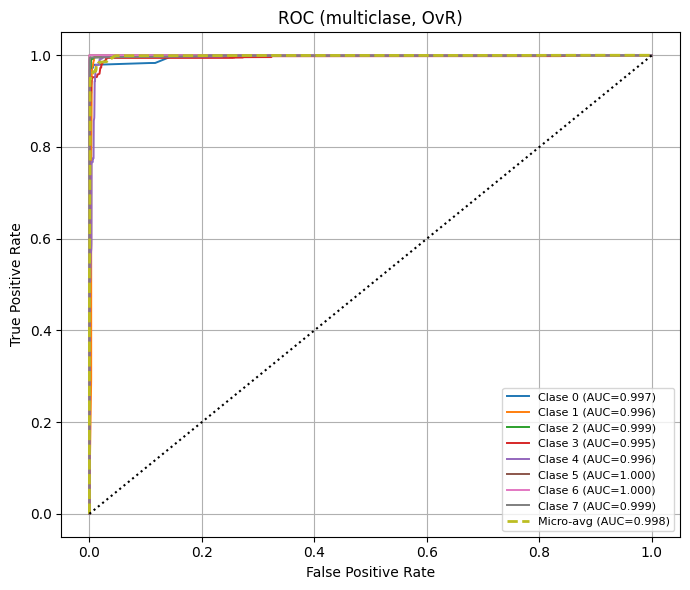


Average Precision multiclase:
  micro-average AP: 0.9908
  clase 0 AP: 0.9922
  clase 1 AP: 0.9345
  clase 2 AP: 0.9996
  clase 3 AP: 0.9747
  clase 4 AP: 0.9266
  clase 5 AP: 1.0000
  clase 6 AP: 1.0000
  clase 7 AP: 0.9947


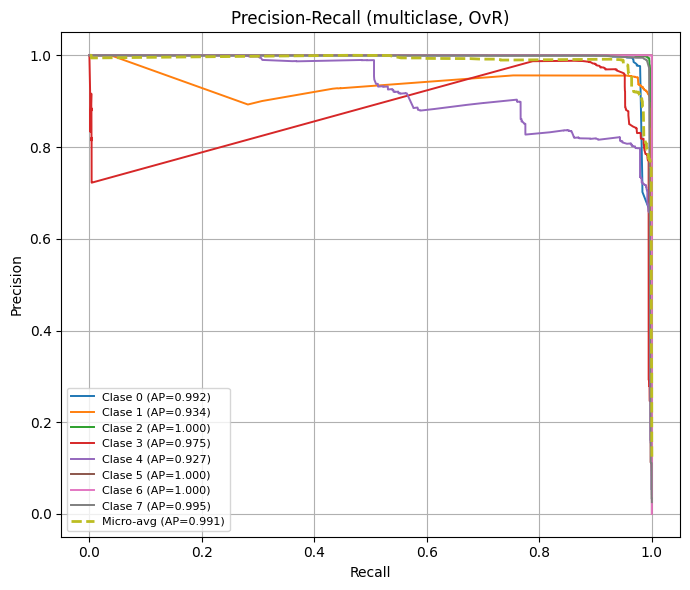

In [31]:
proba_xgb =  xgb.predict_proba(X_te_s)

_ = eval_predictions(y_true=y_te, y_pred=proba_xgb, plot_cm=True, plot_roc=True, plot_pr=True)

## MLP 

In [32]:
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA: True
NVIDIA A2


In [33]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [34]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_size1, hidden_size2, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_size1), nn.ReLU(),
            nn.Linear(hidden_size1, hidden_size2), nn.ReLU(),
            nn.Linear(hidden_size2, out_dim)
        )
    def forward(self, x): return self.net(x)

In [35]:
def train_model(model, Xtr, ytr, Xte, yte, epochs=20, bs=64, lr=1e-3, patience=5, lr_patience=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    Xtr, ytr = torch.tensor(Xtr, dtype=torch.float32), torch.tensor(ytr, dtype=torch.long)
    Xte, yte = torch.tensor(Xte, dtype=torch.float32), torch.tensor(yte, dtype=torch.long)
    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True)
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=lr_patience, factor=0.5)

    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(1, epochs+1):
        # ---- Train ----
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(Xtr)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            logits_val = model(Xte.to(device))
            val_loss = loss_fn(logits_val, yte.to(device)).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ----- update lr -----
        prev_lr = opt.param_groups[0]['lr']
        scheduler.step(val_loss)
        current_lr = opt.param_groups[0]['lr']
        if current_lr != prev_lr:
            print(f'Learning rate changed from {prev_lr:.6f} to {current_lr:.6f}')

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict()
        else:
            patience_counter += 1
            print(f">>>patience_counter: {patience_counter}")
            if patience_counter >= patience:
                print(f"Early stopping en epoch {epoch}")
                break
                
    model.load_state_dict(best_state)

    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Curva de aprendizaje (MLP)")
    plt.legend()
    plt.grid(True)
    plt.show()
                
    #

    return model


In [36]:
model_params = {
    "input_size":  X_tr_s.shape[1],
    "hidden_size1": 128,
    "hidden_size2": 32,
    "output_size": len(np.unique(labels)),
    "epochs": 300,
    "lr": 0.0005,
    "batch_size": 1500
}

mlp = MLP(
    in_dim=model_params["input_size"], 
    hidden_size1=model_params["hidden_size1"],
    hidden_size2=model_params["hidden_size2"], 
    out_dim=model_params["output_size"]
)

Epoch 001 | Train Loss: 0.2341 | Val Loss: 0.0335
Epoch 002 | Train Loss: 0.0249 | Val Loss: 0.0189
Epoch 003 | Train Loss: 0.0156 | Val Loss: 0.0130
Epoch 004 | Train Loss: 0.0114 | Val Loss: 0.0099
Epoch 005 | Train Loss: 0.0089 | Val Loss: 0.0085
Epoch 006 | Train Loss: 0.0073 | Val Loss: 0.0067
Epoch 007 | Train Loss: 0.0062 | Val Loss: 0.0057
Epoch 008 | Train Loss: 0.0054 | Val Loss: 0.0050
Epoch 009 | Train Loss: 0.0048 | Val Loss: 0.0045
Epoch 010 | Train Loss: 0.0043 | Val Loss: 0.0046
>>>patience_counter: 1
Epoch 011 | Train Loss: 0.0039 | Val Loss: 0.0040
Epoch 012 | Train Loss: 0.0036 | Val Loss: 0.0034
Epoch 013 | Train Loss: 0.0033 | Val Loss: 0.0031
Epoch 014 | Train Loss: 0.0031 | Val Loss: 0.0030
Epoch 015 | Train Loss: 0.0029 | Val Loss: 0.0028
Epoch 016 | Train Loss: 0.0027 | Val Loss: 0.0027
Epoch 017 | Train Loss: 0.0026 | Val Loss: 0.0025
Epoch 018 | Train Loss: 0.0024 | Val Loss: 0.0026
>>>patience_counter: 1
Epoch 019 | Train Loss: 0.0023 | Val Loss: 0.0025
>>>p

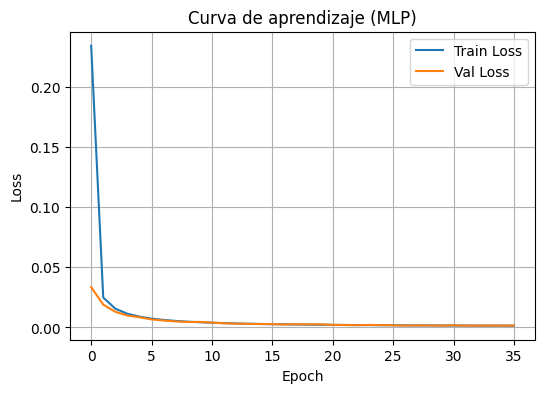

In [37]:
model = train_model(
    mlp, X_tr_s, y_tr, X_val_s, y_val, 
    epochs=model_params["epochs"], 
    bs=model_params["batch_size"], 
    lr=model_params["lr"],
    patience=4,
    lr_patience=3
)

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mlp_trained = model.to(device)

# Pasa Xte al mismo device
with torch.no_grad():
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
    logits_test = mlp_trained(Xte_t)             # logits en device
    proba_mlp = F.softmax(logits_test, dim=1)    # aplicar softmax
    proba_mlp = proba_mlp.cpu().numpy()   

=== Métricas agregadas ===
Macro     -> P: 0.9983 | R: 0.9979 | F1: 0.9981
Weighted  -> P: 0.9994 | R: 0.9994 | F1: 0.9994

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    155333
           1       1.00      1.00      1.00     60352
           2       1.00      1.00      1.00    375765
           3       1.00      1.00      1.00     68033
           4       1.00      1.00      1.00     30976
           5       1.00      1.00      1.00       812
           6       1.00      0.99      0.99       310
           7       1.00      1.00      1.00     18355

    accuracy                           1.00    709936
   macro avg       1.00      1.00      1.00    709936
weighted avg       1.00      1.00      1.00    709936



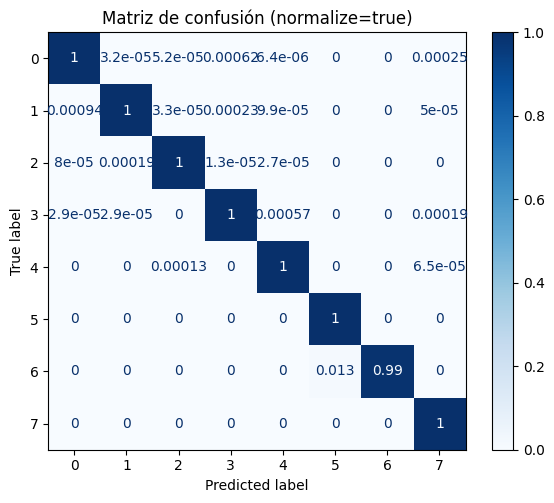


ROC-AUC multiclase:
  micro-average: 1.0000
  macro-average (ovr): 1.0000


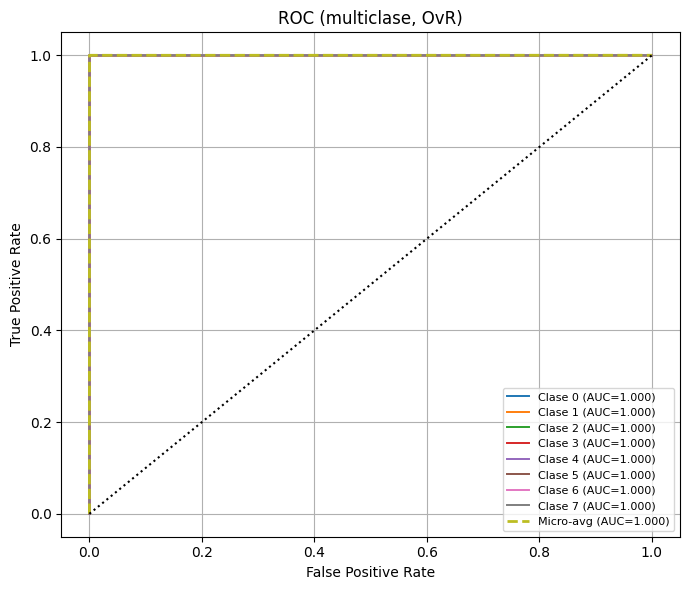


Average Precision multiclase:
  micro-average AP: 1.0000
  clase 0 AP: 1.0000
  clase 1 AP: 1.0000
  clase 2 AP: 1.0000
  clase 3 AP: 1.0000
  clase 4 AP: 1.0000
  clase 5 AP: 1.0000
  clase 6 AP: 1.0000
  clase 7 AP: 1.0000


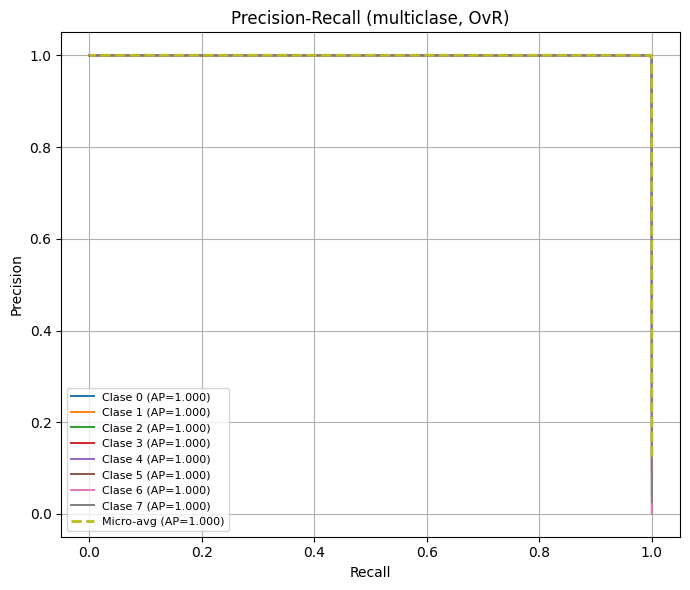

In [39]:
_ = eval_predictions(y_true=y_te, y_pred=proba_mlp, plot_cm=True, plot_roc=True, plot_pr=True)

## Comparar Modelos


=== Resumen de modelos ===


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,MLP,0.999415,0.998322,0.997931,0.998120,0.999416,0.999415,0.999416
1,XGBoost,0.967283,0.968273,0.923657,0.937899,0.968800,0.967283,0.965089
2,DecisionTree,0.977140,0.843112,0.839341,0.841145,0.976231,0.977140,0.976642


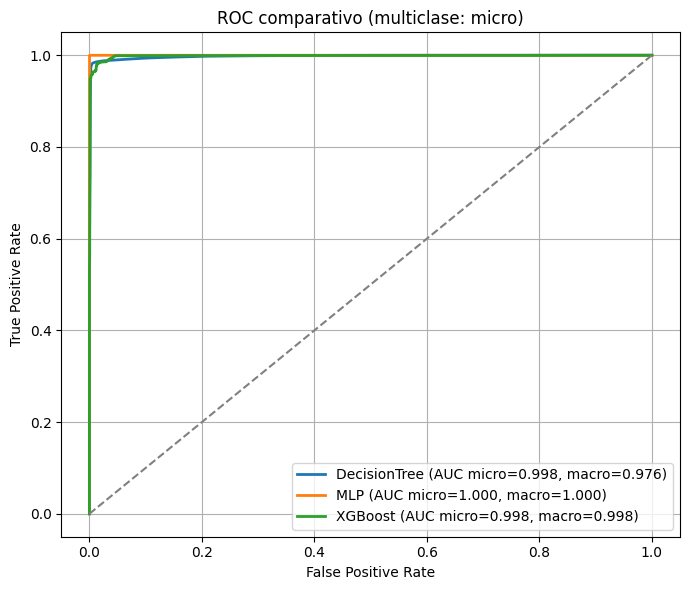

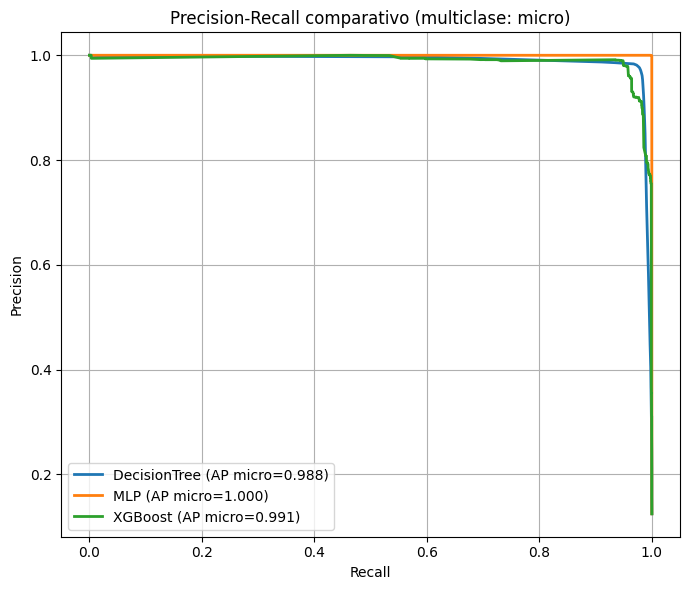

              precision    recall  f1-score   support

           0       0.98      0.97      0.98    155333
           1       0.95      0.98      0.96     60352
           2       0.99      1.00      0.99    375765
           3       0.86      0.96      0.90     68033
           4       0.98      0.55      0.71     30976
           5       1.00      0.94      0.97       812
           6       1.00      1.00      1.00       310
           7       0.99      0.98      0.99     18355

    accuracy                           0.97    709936
   macro avg       0.97      0.92      0.94    709936
weighted avg       0.97      0.97      0.97    709936



In [40]:
res = compare_models(
    y_true=y_te,
    proba_dict={
        "XGBoost": proba_xgb,
        "MLP": proba_mlp,
        "DecisionTree": proba_tree,
    },
    class_labels=np.unique(y_te),
    plot_roc=True,
    plot_pr=True
)

# Resumen en DataFrame:
res["summary"]
# Report por modelo:
print(res["reports"]["XGBoost"])


# Save models

In [41]:
# XGBoost
save_model(xgb, "models/xgb_model.pkl")

# Árbol de decisión
save_model(dt, "models/decision_tree.pkl")

XGBoost model saved at: models/xgb_model_2025-10-09_20-29-17.pkl
Scikit-learn model saved at: models/decision_tree_2025-10-09_20-29-17.pkl


'models/decision_tree_2025-10-09_20-29-17.pkl'

In [ ]:
# MLP (PyTorch)
save_model(mlp_trained, "models/mlp_best.pt")

# ConvNet
save_model(cnn_trained, "models/convnet_best.pt")